#MLP- IBM Attrition

In [1]:
# Mounting to google drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# importing libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, balanced_accuracy_score
from sklearn.metrics import roc_curve, roc_auc_score

In [3]:
# Defining and loading the Datasets
output_dir = '/content/drive/MyDrive/COMM075/data'

df_train = pd.read_csv(os.path.join(output_dir, "train_data_ibm.csv"))
df_test = pd.read_csv(os.path.join(output_dir, "test_data_ibm.csv"))

In [4]:
df_train

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,OverTime,...,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,Attrition
0,1.090194,1.049455,-0.899915,4,2,4,4,2,2.026752,0,...,1,0,0,0,0,0,1,0,0,0
1,-1.634828,-0.523449,-0.899915,1,3,3,1,4,-0.864408,0,...,0,0,0,0,0,0,0,1,0,0
2,0.981193,-0.992080,-0.777610,1,1,3,4,3,2.347706,0,...,1,0,0,0,0,0,0,1,0,0
3,-1.307825,-0.453653,0.445433,1,2,3,1,3,-0.956202,0,...,0,0,0,0,0,1,0,1,0,0
4,0.654191,0.491086,-0.043784,5,4,3,2,3,-0.185956,1,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1171,-1.525827,-0.939733,-0.288393,3,3,3,1,4,-0.917721,1,...,0,0,0,0,0,1,1,0,0,1
1172,0.109186,0.511028,-0.899915,2,2,3,2,1,0.075020,0,...,0,0,0,0,1,0,1,0,0,0
1173,-1.634828,-1.463203,-0.166088,1,2,1,1,1,-0.879886,0,...,0,0,0,0,0,0,0,1,0,0
1174,-0.108815,-0.932255,-0.899915,4,4,3,2,2,0.089853,1,...,0,0,0,1,0,0,0,1,0,0


In [5]:
df_test

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,OverTime,...,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,Attrition
0,-1.416826,0.064832,0.445433,2,4,3,1,2,-0.969745,0,...,0,0,0,0,0,1,0,1,0,0
1,0.763191,0.780241,-0.899915,1,1,4,1,4,-0.974474,0,...,0,0,0,1,0,0,0,1,0,0
2,-0.653820,-0.289134,-0.288393,3,3,2,3,4,1.077650,0,...,1,0,0,0,0,0,1,0,0,0
3,0.763191,0.984644,-0.655306,2,3,4,5,1,2.718533,0,...,1,0,0,0,0,0,1,0,0,0
4,-0.108815,-1.211439,-0.043784,3,4,2,1,3,-0.678457,1,...,0,0,0,1,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
289,0.654191,-1.395900,-0.899915,3,2,3,1,4,-0.645997,0,...,0,0,0,0,0,0,0,0,1,0
290,0.763191,-1.580361,-1.022219,4,2,4,2,1,-0.324828,0,...,0,0,0,0,0,0,0,1,0,0
291,-0.108815,1.625272,0.445433,5,2,2,2,1,-0.088144,1,...,0,0,0,0,1,0,1,0,0,1
292,2.071202,1.124236,-1.022219,2,1,3,1,1,-0.962651,0,...,0,0,0,1,0,0,0,1,0,0


In [6]:
# Seperate features and target
X_train = df_train.drop("Attrition", axis=1)
y_train = df_train["Attrition"]

X_test = df_test.drop("Attrition", axis=1)
y_test = df_test["Attrition"]

In [7]:
print(y_train.unique())

[0 1]


In [8]:
print(X_train.dtypes)

Age                                  float64
DailyRate                            float64
DistanceFromHome                     float64
Education                              int64
EnvironmentSatisfaction                int64
JobInvolvement                         int64
JobLevel                               int64
JobSatisfaction                        int64
MonthlyIncome                        float64
OverTime                               int64
PerformanceRating                      int64
RelationshipSatisfaction               int64
StockOptionLevel                       int64
TotalWorkingYears                    float64
TrainingTimesLastYear                float64
WorkLifeBalance                        int64
YearsAtCompany                       float64
YearsInCurrentRole                   float64
YearsWithCurrManager                 float64
BusinessTravel_Non-Travel              int64
BusinessTravel_Travel_Frequently       int64
BusinessTravel_Travel_Rarely           int64
Department

In [9]:
# Using stratifiedkfold cross validation
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# MLP model
mlp = MLPClassifier(
    max_iter=500,
    random_state=42
)

# Grid search parameters
param_grid = {
    'hidden_layer_sizes': [(32,),(64,),(64,32),(128,64)],

    'activation': ['relu','tanh'],

    'solver': ['adam'],

    'alpha': [0.0001,0.001,0.01],

    'learning_rate_init': [0.001,0.01]}

# Grid search CV
grid_search = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=skf,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best Parameters")
print(grid_search.best_params_)

print("Best Cross Validation Score")
print(grid_search.best_score_)

# Best model
best_mlp = grid_search.best_estimator_
# Predictions
y_pred = best_mlp.predict(X_test)
y_prob = best_mlp.predict_proba(X_test)[:, 1]

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters
{'activation': 'tanh', 'alpha': 0.01, 'hidden_layer_sizes': (64,), 'learning_rate_init': 0.001, 'solver': 'adam'}
Best Cross Validation Score
0.717320124677746


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [10]:
# Evaluation Metrics
print("MLP Classification Report IBM")
print(classification_report(y_test, y_pred))

print("MLP Evaluation Metrics IBM")

macrof1_score = f1_score(y_test, y_pred, average='macro')
print("Macro F1 Score:", round(macrof1_score,4))
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy,4))
weighted_f1 = f1_score(y_test, y_pred, average='weighted')
print("Weighted F1-Score:", round(weighted_f1, 4))
balanced_acc = balanced_accuracy_score(y_test, y_pred)
print("Balanced Accuracy:", round(balanced_acc, 4))

MLP Classification Report IBM
              precision    recall  f1-score   support

           0       0.90      0.94      0.91       247
           1       0.56      0.43      0.48        47

    accuracy                           0.85       294
   macro avg       0.73      0.68      0.70       294
weighted avg       0.84      0.85      0.85       294

MLP Evaluation Metrics IBM
Macro F1 Score: 0.6984
Accuracy: 0.8537
Weighted F1-Score: 0.8456
Balanced Accuracy: 0.6804


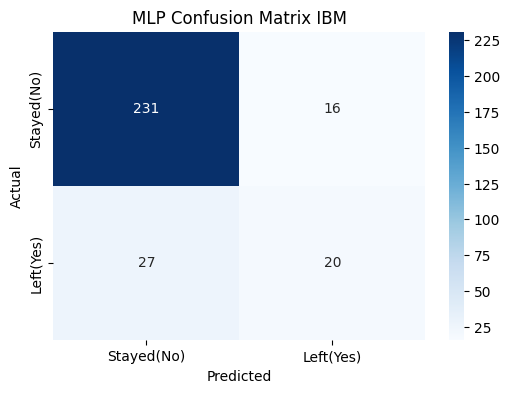

In [11]:
# Confusion Metrics
cm = confusion_matrix(y_test, y_pred)
display_labels = ["Stayed(No)", "Left(Yes)"]

plt.figure(figsize=(6, 4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels= display_labels, yticklabels= display_labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MLP Confusion Matrix IBM")

plt.show()

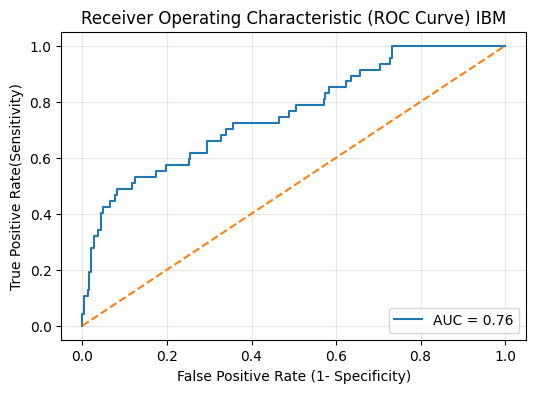

In [12]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)
plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate (1- Specificity)")
plt.ylabel("True Positive Rate(Sensitivity)")
plt.title("Receiver Operating Characteristic (ROC Curve) IBM")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

In [13]:
# Create ROC dataframe
roc_data = pd.DataFrame({'FPR': fpr,'TPR': tpr})

# Save ROC values
roc_data.to_csv(
    os.path.join(
        output_dir,
        'mlp_roc_values_IBM.csv'
    ),
    index=False
)

print("ROC values saved successfully.")

ROC values saved successfully.


In [14]:
auc_df = pd.DataFrame({'Model': ['MLP'],'AUC': [auc_score]})

auc_df.to_csv(
    os.path.join(
        output_dir,
        'mlp_auc_score_IBM.csv'
    ),
    index=False
)

print("AUC score saved successfully.")

AUC score saved successfully.


In [15]:
# Results
results = pd.DataFrame({

    "Metric": ["macrof1_score", "Accuracy", "weighted_f1", "balanced_acc"],

    "Value": [macrof1_score, accuracy, weighted_f1, balanced_acc]})

results.to_csv(
    os.path.join(output_dir, "mlp_results_ibm.csv"),
    index=False
)

print("Results saved successfully.")

Results saved successfully.


#MLP-Adult Census

In [16]:
# Mounting to google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
# importing libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, balanced_accuracy_score
from sklearn.metrics import roc_curve, roc_auc_score

In [18]:
# Defining and loading the Datasets
output_dir = '/content/drive/MyDrive/COMM075/data'

df_train = pd.read_csv(os.path.join(output_dir, "train_data.csv"))
df_test = pd.read_csv(os.path.join(output_dir, "test_data.csv"))

In [19]:
df_train

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,capital_net,capital_gain_log,capital_loss_log,capital_net_log,...,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Unknown,native-country_Vietnam,native-country_Yugoslavia,income_encoded
0,37,193106,13,0,0,30,0,0.0,0.000000,0.0,...,False,False,False,False,False,True,False,False,False,0
1,56,216636,8,0,1651,40,-1651,0.0,7.409742,0.0,...,False,False,False,False,False,True,False,False,False,0
2,53,126977,9,0,0,35,0,0.0,0.000000,0.0,...,False,False,False,False,False,True,False,False,False,0
3,72,205343,7,0,0,40,0,0.0,0.000000,0.0,...,False,False,False,False,False,True,False,False,False,0
4,46,106705,14,0,0,38,0,0.0,0.000000,0.0,...,False,False,False,False,False,True,False,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39068,45,37718,13,0,0,40,0,0.0,0.000000,0.0,...,False,False,False,False,False,True,False,False,False,1
39069,58,223400,13,0,0,20,0,0.0,0.000000,0.0,...,False,False,False,False,False,True,False,False,False,1
39070,61,229062,10,0,1887,40,-1887,0.0,7.543273,0.0,...,False,False,False,False,False,True,False,False,False,1
39071,38,81965,11,0,0,40,0,0.0,0.000000,0.0,...,False,False,False,False,False,True,False,False,False,0


In [20]:
df_test

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,capital_net,capital_gain_log,capital_loss_log,capital_net_log,...,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Unknown,native-country_Vietnam,native-country_Yugoslavia,income_encoded
0,30,378009,9,0,0,40,0,0.000000,0.0,0.000000,...,False,False,False,False,False,True,False,False,False,0
1,54,55861,12,0,0,39,0,0.000000,0.0,0.000000,...,False,False,False,False,False,True,False,False,False,0
2,21,204226,10,0,0,35,0,0.000000,0.0,0.000000,...,False,False,False,False,False,True,False,False,False,0
3,35,306678,9,2885,0,40,2885,7.967627,0.0,7.967627,...,False,False,False,False,False,True,False,False,False,0
4,42,121012,10,0,0,45,0,0.000000,0.0,0.000000,...,False,False,False,False,False,True,False,False,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9764,37,164526,13,0,0,40,0,0.000000,0.0,0.000000,...,False,False,False,False,False,True,False,False,False,0
9765,34,156890,9,0,0,50,0,0.000000,0.0,0.000000,...,False,False,False,False,False,True,False,False,False,0
9766,59,182460,9,0,0,30,0,0.000000,0.0,0.000000,...,False,False,False,False,False,True,False,False,False,1
9767,29,79481,10,0,0,40,0,0.000000,0.0,0.000000,...,False,False,False,False,False,True,False,False,False,0


In [21]:
# Seperate features and target
X_train = df_train.drop("income_encoded", axis=1)
y_train = df_train["income_encoded"]

X_test = df_test.drop("income_encoded", axis=1)
y_test = df_test["income_encoded"]

In [22]:
print(y_train.unique())

[0 1]


In [23]:
print(X_train.dtypes)

age                               int64
fnlwgt                            int64
education-num                     int64
capital-gain                      int64
capital-loss                      int64
                                  ...  
native-country_Trinadad&Tobago     bool
native-country_United-States       bool
native-country_Unknown             bool
native-country_Vietnam             bool
native-country_Yugoslavia          bool
Length: 89, dtype: object


In [24]:
# Using stratifiedkfold cross validation
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# MLP model
mlp = MLPClassifier(
    max_iter=500,
    early_stopping=True,
    batch_size=64,
    random_state=42
)

# Grid search parameters
param_grid = {
    'hidden_layer_sizes': [(64,),(64,32),(128,64)],

    'activation': ['relu'],

    'solver': ['adam'],

    'alpha': [0.0001,0.001,0.01],

    'learning_rate_init': [0.001]}

# Grid search CV
grid_search = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=skf,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best Parameters")
print(grid_search.best_params_)

print("Best Cross Validation Score")
print(grid_search.best_score_)

# Best model
best_mlp = grid_search.best_estimator_
# Predictions
y_pred = best_mlp.predict(X_test)
y_prob = best_mlp.predict_proba(X_test)[:, 1]

# Threshold tuning
thresholds = np.arange(0.1, 0.9, 0.05)

best_threshold = 0
best_f1 = 0

for threshold in thresholds:

    y_pred_temp = (y_prob >= threshold).astype(int)

    score = f1_score(
        y_test,
        y_pred_temp,
        average='macro'
    )

    print(
        "Threshold:",
        threshold,
        "Macro F1:",
        score
    )

    if score > best_f1:
        best_f1 = score
        best_threshold = threshold

print("Best Threshold:", best_threshold)
print("Best Macro F1:", best_f1)

# 16. FINAL PREDICTIONS
y_pred = (
    y_prob >= best_threshold
).astype(int)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best Parameters
{'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (64,), 'learning_rate_init': 0.001, 'solver': 'adam'}
Best Cross Validation Score
0.6701059446582388
Threshold: 0.1 Macro F1: 0.7243113206405336
Threshold: 0.15000000000000002 Macro F1: 0.7242627768102115
Threshold: 0.20000000000000004 Macro F1: 0.7245924070306182
Threshold: 0.25000000000000006 Macro F1: 0.7249134424926575
Threshold: 0.30000000000000004 Macro F1: 0.7249312290311946
Threshold: 0.3500000000000001 Macro F1: 0.7245491497876119
Threshold: 0.40000000000000013 Macro F1: 0.7239651289436011
Threshold: 0.45000000000000007 Macro F1: 0.7243978259372456
Threshold: 0.5000000000000001 Macro F1: 0.7237058694011678
Threshold: 0.5500000000000002 Macro F1: 0.7234215990554367
Threshold: 0.6000000000000002 Macro F1: 0.7239644829968828
Threshold: 0.6500000000000001 Macro F1: 0.7237690046459815
Threshold: 0.7000000000000002 Macro F1: 0.7236905745582205
Thr

In [25]:
# Evaluation Metrics
print("MLP Classification Report Adult Census")
print(classification_report(y_test, y_pred))

print("MLP Evaluation Metrics Adult Census")

macrof1_score = f1_score(y_test, y_pred, average='macro')
print("Macro F1 Score:",round(macrof1_score,4))
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:",round(accuracy,4))
weighted_f1 = f1_score(y_test, y_pred, average='weighted')
print("Weighted F1-Score:",round(weighted_f1, 4))
balanced_acc = balanced_accuracy_score(y_test, y_pred)
print("Balanced Accuracy:",round(balanced_acc, 4))

MLP Classification Report Adult Census
              precision    recall  f1-score   support

           0       0.86      0.91      0.88      7431
           1       0.64      0.51      0.57      2338

    accuracy                           0.81      9769
   macro avg       0.75      0.71      0.72      9769
weighted avg       0.80      0.81      0.81      9769

MLP Evaluation Metrics Adult Census
Macro F1 Score: 0.7249
Accuracy: 0.8145
Weighted F1-Score: 0.8068
Balanced Accuracy: 0.71


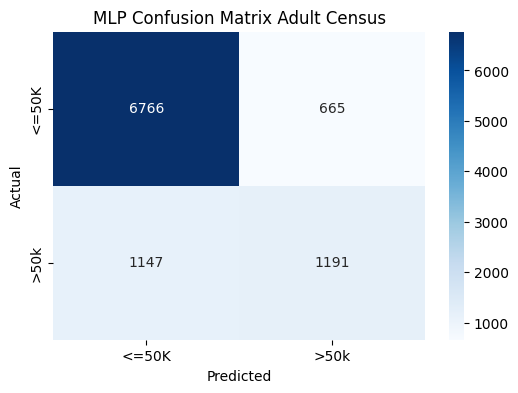

In [26]:
# Confusion Metrics
cm = confusion_matrix(y_test, y_pred)
display_labels = ["<=50K", ">50k"]

plt.figure(figsize=(6, 4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels= display_labels, yticklabels= display_labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MLP Confusion Matrix Adult Census")

plt.show()

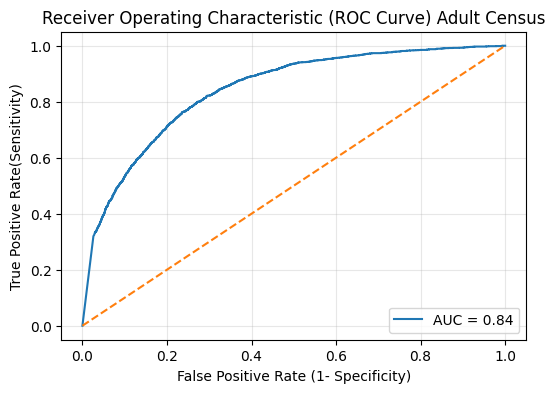

In [27]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)
plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate (1- Specificity)")
plt.ylabel("True Positive Rate(Sensitivity)")
plt.title("Receiver Operating Characteristic (ROC Curve) Adult Census")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

In [28]:
# Create ROC dataframe
roc_data = pd.DataFrame({'FPR': fpr,'TPR': tpr})

# Save ROC values
roc_data.to_csv(
    os.path.join(
        output_dir,
        'mlp_roc_values_adult.csv'
    ),
    index=False
)

print("ROC values saved successfully.")

ROC values saved successfully.


In [29]:
auc_df = pd.DataFrame({'Model': ['MLP'],'AUC': [auc_score]})

auc_df.to_csv(
    os.path.join(
        output_dir,
        'mlp_auc_score_adult.csv'
    ),
    index=False
)

print("AUC score saved successfully.")

AUC score saved successfully.


In [30]:
# Results
results = pd.DataFrame({

    "Metric": ["macrof1_score", "Accuracy", "weighted_f1", "balanced_acc"],

    "Value": [macrof1_score, accuracy, weighted_f1, balanced_acc]})

results.to_csv(
    os.path.join(output_dir, "mlp_results_adult.csv"),
    index=False
)

print("Results saved successfully.")

Results saved successfully.
